shape (240, 240, 155)
datatype: float64
min value 0.0
max value: 625.0


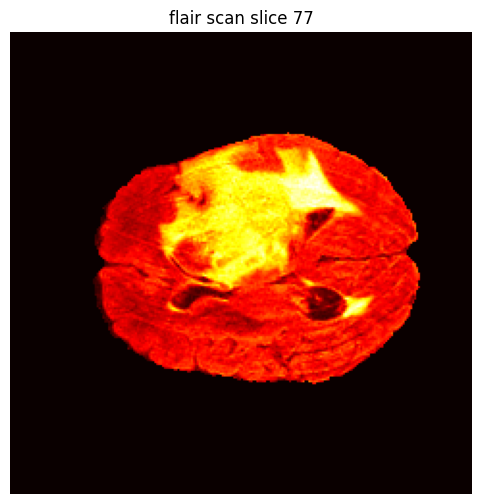

mask shape: (240, 240, 155)
unique values in mask: [0. 1. 2. 4.]


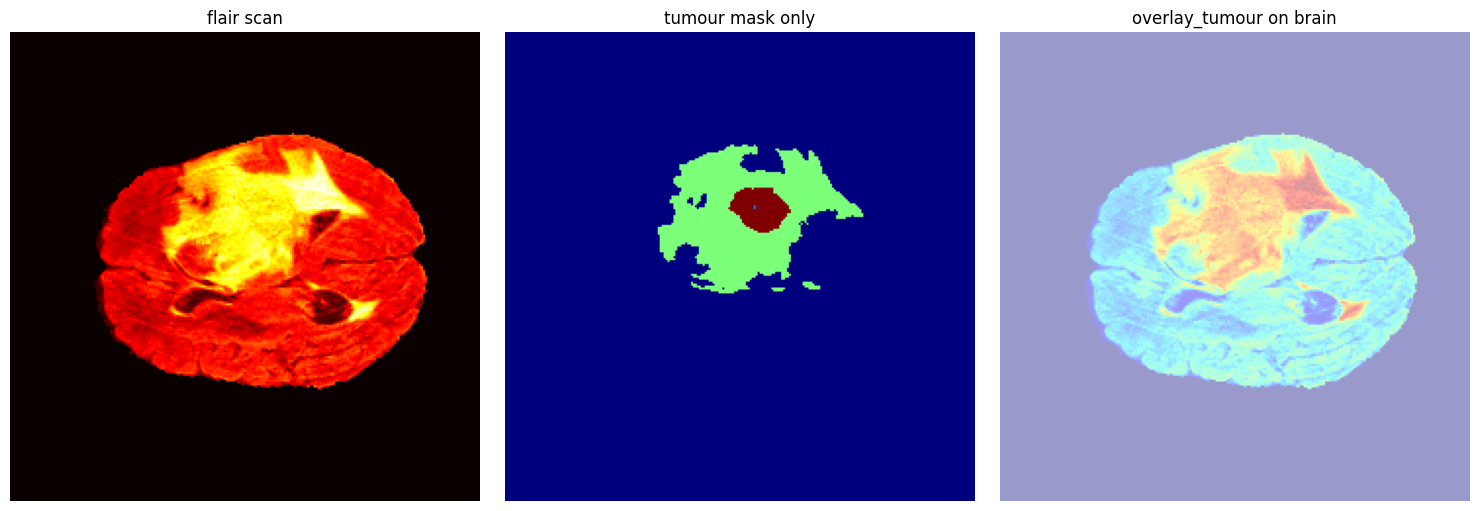

In [4]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt

img = nib.load(r"C:\Users\anjan\ML-Journey\MRI-Project\data\BraTS2020_TrainingData\MICCAI_BraTS2020_TrainingData\BraTS20_Training_001\BraTS20_Training_001_flair.nii")
data = img.get_fdata()

print("shape", data.shape)
print("datatype:", data.dtype)
print("min value", data.min())
print("max value:", data.max())

slice_index = 77
plt.figure(figsize=(6,6))
plt.imshow(data[:,:,slice_index], cmap='hot')
plt.title(f'flair scan slice {slice_index}')
plt.axis('off')
plt.show()
mask = nib.load(r"C:\Users\anjan\ML-Journey\MRI-Project\data\BraTS2020_TrainingData\MICCAI_BraTS2020_TrainingData\BraTS20_Training_001\BraTS20_Training_001_seg.nii")
mask_data = mask.get_fdata()
print("mask shape:",mask_data.shape)
print("unique values in mask:",np.unique(mask_data))
slice_index = 77
fig,axes = plt.subplots(1,3,figsize=(15,5))
axes[0].imshow(data[:,:,slice_index],cmap='hot')
axes[0].set_title('flair scan')
axes[0].axis('off')
axes[1].imshow(mask_data[:,:,slice_index],cmap='jet')
axes[1].set_title('tumour mask only')
axes[1].axis('off')
axes[2].imshow(data[:,:,slice_index],cmap='jet',alpha=0.4)
axes[2].set_title('overlay_tumour on brain')
axes[2].axis('off')
plt.tight_layout()
plt.show()

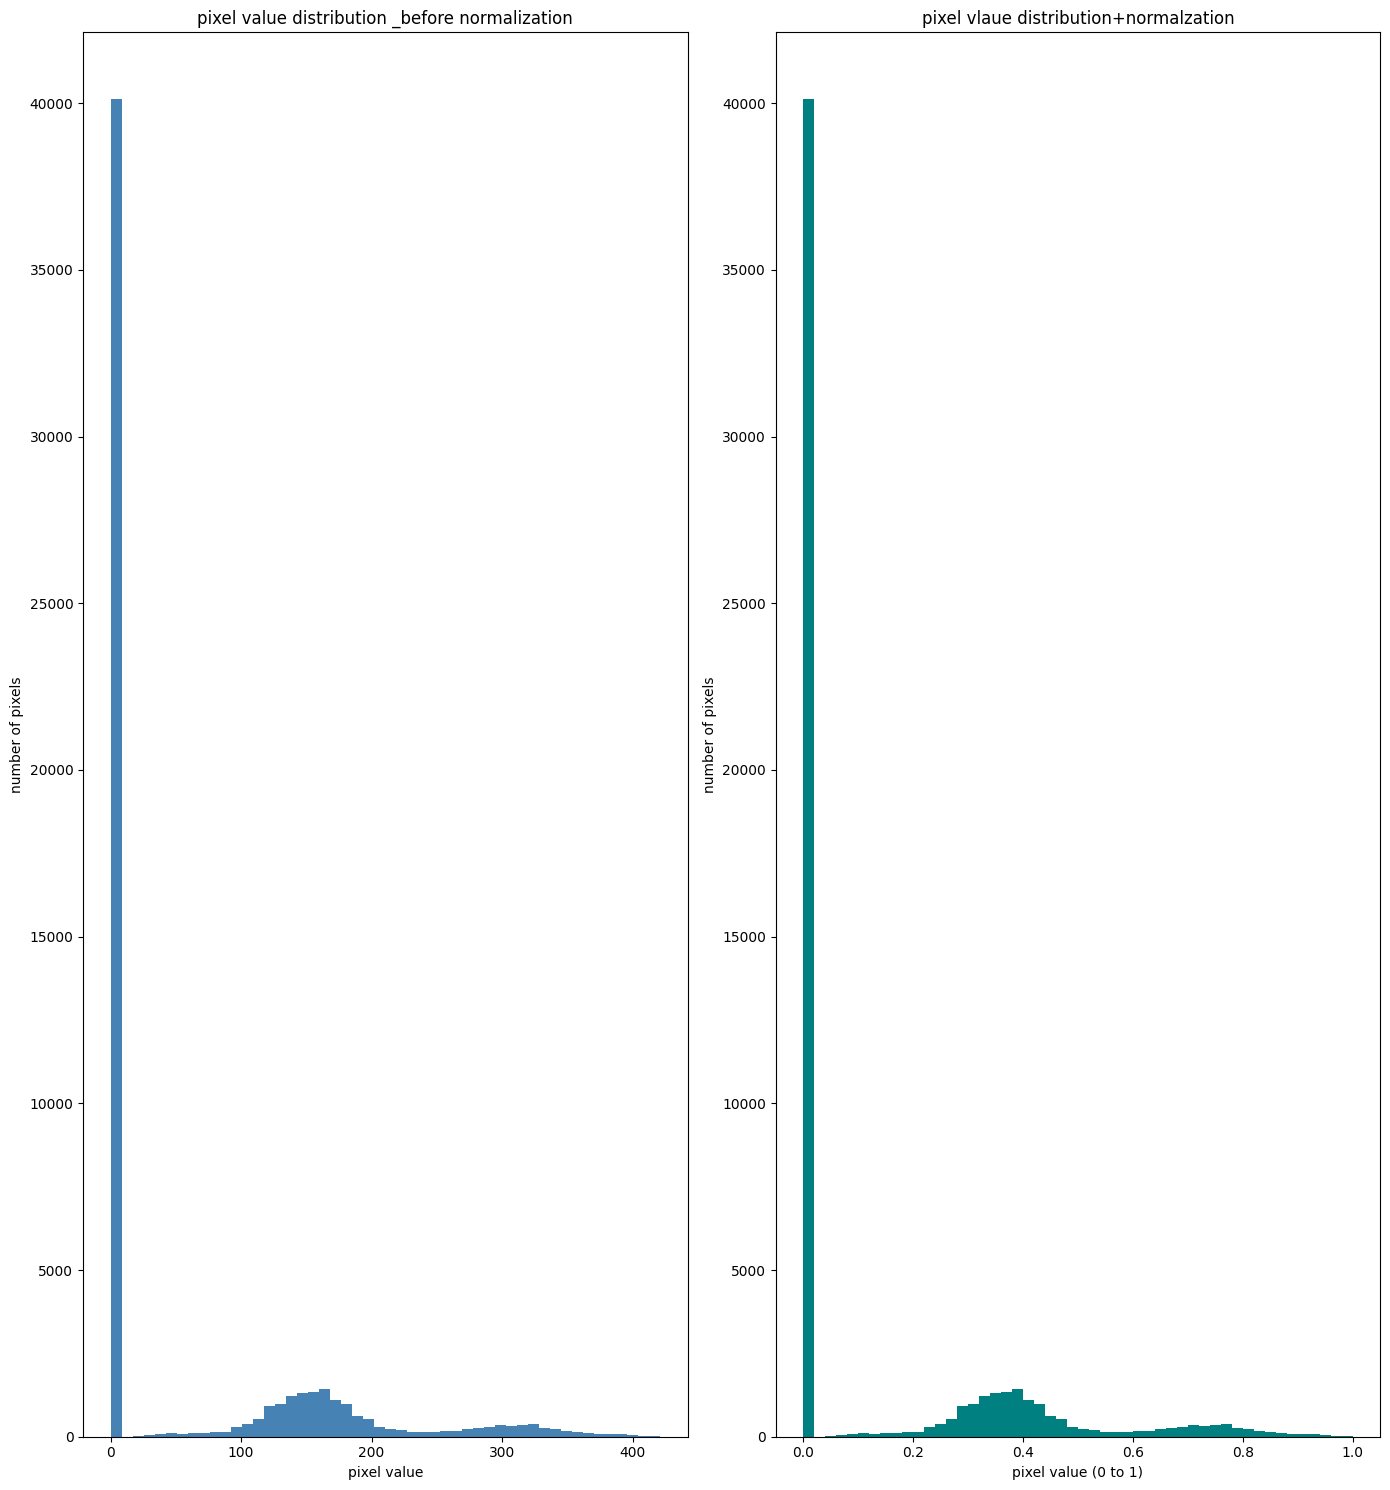

Before — min: 0.0 max: 421.0
After  — min: 0.0 max: 1.0


In [5]:
import numpy as np
import matplotlib.pyplot as plt
slice_index = 77
brain_slice = data[:,:,slice_index]
fig,axes = plt.subplots(1,2,figsize=(14,15))
axes[0].hist(brain_slice.flatten(),bins=50,color='steelblue',edgecolor = 'none')
axes[0].set_title('pixel value distribution _before normalization')
axes[0].set_xlabel('pixel value')
axes[0].set_ylabel('number of pixels')
normalized_slice = (brain_slice-brain_slice.min())/(brain_slice.max()-brain_slice.min())
axes[1].hist(normalized_slice.flatten(),bins=50,color='teal',edgecolor = 'none')
axes[1].set_title('pixel vlaue distribution+normalzation')
axes[1].set_xlabel('pixel value (0 to 1)')
axes[1].set_ylabel('number of pixels')
plt.tight_layout()
plt.show()
print("Before — min:", brain_slice.min(), "max:", brain_slice.max())
print("After  — min:", round(normalized_slice.min(), 4), "max:", round(normalized_slice.max(), 4))